[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# Basketball AI: How to Detect, Track, and Identify Basketball Players

---

[![Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/basketball-ai-how-to-detect-track-and-identify-basketball-players.ipynb)
[![Roboflow](https://raw.githubusercontent.com/roboflow-ai/notebooks/main/assets/badges/roboflow-blogpost.svg)](https://blog.roboflow.com/identify-basketball-players)

![identify-basketball-players-2](https://storage.googleapis.com/com-roboflow-marketing/notebooks/basketball-ai-how-to-detect-track-and-identify-basketball-players-2.png)

![identify-basketball-players-1](https://storage.googleapis.com/com-roboflow-marketing/notebooks/basketball-ai-how-to-detect-track-and-identify-basketball-players-1.png)

## Environment setup

### Configure your API keys

To run this notebook, you need to provide your HuggingFace Token and Roboflow API key.  

- The `ROBOFLOW_API_KEY` is required to pull the fine-tuned RF-DETR player detector and the SmolVLM2 number recognizer from Roboflow Universe.  
- The `HF_TOKEN` is required to pull the pretrained SigLIP model from HuggingFace.  

Follow these steps:  

- Open your [`HuggingFace Settings`](https://huggingface.co/settings) page. Click `Access Tokens` then `New Token` to generate a new token.  
- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.  
- In Colab, go to the left pane and click on `Secrets` (🔑).  
    - Store the HuggingFace Access Token under the name `HF_TOKEN`.  
    - Store the Roboflow API Key under the name `ROBOFLOW_API_KEY`.  

In [2]:
import os
from pathlib import Path
from dotenv import load_dotenv

# Find repo root (notebook may run with cwd = repo or notebooks/)
REPO_ROOT = Path.cwd()
if (REPO_ROOT / "notebooks").is_dir() and REPO_ROOT.name != "workspace":
    REPO_ROOT = REPO_ROOT.parent if (REPO_ROOT.parent / ".env").exists() else REPO_ROOT
elif (REPO_ROOT / "notebooks").is_dir() and (REPO_ROOT / ".env").exists():
    pass  # cwd is repo root
elif REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

load_dotenv(REPO_ROOT / ".env", override=False)

if os.environ.get("ROBOFLOW_API_KEY"):
    os.environ.setdefault("API_KEY", os.environ["ROBOFLOW_API_KEY"])

assert os.environ.get("HF_TOKEN"), "Set HF_TOKEN in .env"
assert os.environ.get("ROBOFLOW_API_KEY"), "Set ROBOFLOW_API_KEY in .env"
print("API keys loaded from .env")

API keys loaded from .env


### Check GPU availability

Let's make sure we have access to a GPU. Run the `nvidia-smi` command to verify. If you run into issues, go to `Runtime` -> `Change runtime type`, select `T4 GPU` or `L4 GPU`, and then click `Save`.

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [3]:
from pathlib import Path

HOME = REPO_ROOT if "REPO_ROOT" in dir() else Path.cwd()
if HOME.name == "Basketball-player-tracking":
    HOME = HOME.parent
    
print("HOME:", HOME)

HOME: /workspace


## Install SAM2 real-time

We will use `segment-anything-2-real-time`, an open-source fork of Meta’s Segment Anything Model 2 optimized for real-time inference. After installing the repository, we will also download the required checkpoint files.


In [4]:
SAM2_DIR = HOME / "segment-anything-2-real-time"
assert SAM2_DIR.exists(), f"Missing {SAM2_DIR} — clone SAM2 there first"

# %cd {SAM2_DIR}
# !{REPO_ROOT}/.venv/bin/pip install -e . --no-build-isolation -q
# !{REPO_ROOT}/.venv/bin/python setup.py build_ext --inplace
# !(cd checkpoints && bash download_ckpts.sh)
# !cp checkpoints/sam2.1_hiera_large.pt /workspace/model-cache/checkpoints/

## Install dependencies

In [5]:
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "show", "inference-gpu", "supervision", "sports"], check=True)
print("Dependencies OK in active kernel.")

Name: inference-gpu
Version: 1.3.2
Summary: With no prior knowledge of machine learning or device-specific deployment, you can deploy a computer vision model to a range of devices and environments using Roboflow Inference.
Home-page: https://github.com/roboflow/inference
Author: Roboflow
Author-email: help@roboflow.com
License: 
Location: /workspace/Basketball-player-tracking/.venv/lib/python3.11/site-packages
Requires: aiohttp, aiortc, anthropic, APScheduler, asyncua, av, backoff, boto3, botocore, cachetools, click, cython, dataclasses-json, docker, fastapi, filelock, httpx, inference-models, networkx, numpy, nvidia-ml-py, onnxruntime-gpu, onvif-zeep-async, openai, opencv-contrib-python, opencv-python, packaging, paho-mqtt, pandas, pillow, prometheus-fastapi-instrumentator, psutil, py-cpuinfo, pybase64, pydantic, pydantic-settings, pydot, pylogix, pymodbus, pytest, python-dotenv, PyYAML, qrcode, redis, requests, requests-toolbelt, rich, scikit-image, setuptools, shapely, simple-pid, s

Set the ONNX Runtime execution provider to CUDA to ensure model inference runs on the GPU.

In [6]:
import os

# Use GPU ONNX when available; fall back to CPU. Must be set before importing inference.
os.environ["ONNXRUNTIME_EXECUTION_PROVIDERS"] = "CUDAExecutionProvider,CPUExecutionProvider"

# Cursor/VS Code cannot render saved ipywidget outputs offline — use plain-text progress bars.
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
import rich.console as _rich_console
_rich_console._is_jupyter = lambda: False

### Source videos

As an example, we will use sample videos from Game 1 of the 2025 NBA Playoffs between the Boston Celtics and the New York Knicks. We prepared 10 sample videos from this game.

In [7]:
SOURCE_VIDEO_DIRECTORY = HOME / "source"
# Upload or copy .mp4 files here; Colab used gdown from Google Drive
print(SOURCE_VIDEO_DIRECTORY)

/workspace/source


In [8]:
!ls -la {SOURCE_VIDEO_DIRECTORY}

total 21528
drwxrwxrwx 2 root root  2001625 Jul 30 18:28 .
drwxrwxrwx 7 root root  3001998 Aug 15 13:13 ..
-rw-rw-rw- 1 root root  6596558 Jul 30 18:28 boston-celtics-new-york-knicks-game-1-q1-03.16-03.11.mp4
-rw-rw-rw- 1 root root 10443619 Jul 30 18:29 boston-celtics-new-york-knicks-game-1-q1-04.28-04.20.mp4


In [9]:
SOURCE_VIDEO_PATH = SOURCE_VIDEO_DIRECTORY / "boston-celtics-new-york-knicks-game-1-q1-04.28-04.20.mp4"

### Team rosters

We are preparing player rosters for both teams. We load the official lists that link jersey numbers to player names. These mappings will let us replace detected numbers with real names, making the final analytics clear and readable.

In [10]:
TEAM_ROSTERS = {
  "New York Knicks": {
    "55": "Hukporti",
    "1": "Payne",
    "0": "Wright",
    "11": "Brunson",
    "3": "Hart",
    "32": "Towns",
    "44": "Shamet",
    "25": "Bridges",
    "2": "McBride",
    "23": "Robinson",
    "8": "Anunoby",
    "4": "Dadiet",
    "5": "Achiuwa",
    "13": "Kolek"
  },
  "Boston Celtics": {
    "42": "Horford",
    "55": "Scheierman",
    "9": "White",
    "20": "Davison",
    "7": "Brown",
    "0": "Tatum",
    "27": "Walsh",
    "4": "Holiday",
    "8": "Porzingis",
    "40": "Kornet",
    "88": "Queta",
    "11": "Pritchard",
    "30": "Hauser",
    "12": "Craig",
    "26": "Tillman"
  }
}

TEAM_COLORS = {
    "New York Knicks": "#006BB6",
    "Boston Celtics": "#007A33"
}

## Import dependencies (7minutes)

In [11]:
from IPython.display import Video
from typing import Dict, List, Optional, Union, Iterable, Tuple
from operator import itemgetter

import cv2
import numpy as np
import torch
from tqdm import tqdm

import supervision as sv
from inference import get_model
from sports import (
    clean_paths,
    ConsecutiveValueTracker,
    TeamClassifier,
    MeasurementUnit,
    ViewTransformer
)
from sports.basketball import (
    CourtConfiguration,
    League,
    draw_court,
    draw_points_on_court,
    draw_paths_on_court,
    draw_made_and_miss_on_court,
    ShotEventTracker
)

[08/15/26 13:21:46] WARNING  Your inference package version 1.3.7 ]8;id=4137539;file:///workspace/Basketball-player-tracking/.venv/lib/python3.11/site-packages/inference/core/__init__.py\__init__.py]8;;\:]8;id=4137540;file:///workspace/Basketball-player-tracking/.venv/lib/python3.11/site-packages/inference/core/__init__.py#50\50]8;;\
                             is out of date! Please upgrade to                  
                             version 1.4.1 of inference for the                 
                             latest features and bug fixes by                   
                             running `pip install --upgrade                     
                             inference`.                                        


ModelDependencyMissing: Your `inference` configuration does not support SAM model. Use pip install 'inference[sam]' to install missing requirements.To suppress this warning, set CORE_MODEL_SAM_ENABLED to False.
[transformers] `DepthProImageProcessorFast` is deprecated. The `Fast` suffix for image processors has been removed; use `DepthProImageProcessor` instead.
ModelDependencyMissing: Your `inference` configuration does not support YoloWorld model. Use pip install 'inference[yolo-world]' to install missing requirements.To suppress this warning, set CORE_MODEL_YOLO_WORLD_ENABLED to False.


In [12]:
import torch
import bitsandbytes
import PIL

print("PyTorch:", torch.__version__)
print("CUDA compiled:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
print("bitsandbytes:", bitsandbytes.__version__)
print("Pillow:", PIL.__version__)

PyTorch: 2.11.0+cu128
CUDA compiled: 12.8
CUDA available: True
GPU: NVIDIA A40
bitsandbytes: 0.47.0
Pillow: 12.3.0


## Object detection

The model used in this notebook detects the following classes: `ball`, `ball-in-basket`, `number`, `player`, `player-in-possession`, `player-jump-shot`, `player-layup-dunk`, `player-shot-block`, `referee`, and `rim`. These classes enable tracking of game events, player actions, and ball location for basketball analytics.

### Load RF-DETR object detection model

In [13]:
PLAYER_DETECTION_MODEL_ID = "basketball-player-detection-3-ycjdo/4"
PLAYER_DETECTION_MODEL_CONFIDENCE = 0.4
PLAYER_DETECTION_MODEL_IOU_THRESHOLD = 0.9
PLAYER_DETECTION_MODEL = get_model(model_id=PLAYER_DETECTION_MODEL_ID)

COLOR = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

## Player tracking

We are switching from frame-wise boxes to temporal tracks. SAM2 yields per-player masks and stable track IDs that persist through occlusions and re-entries.

### Load SAM2 tracking model

We are loading a SAM2 checkpoint and config into the camera predictor. The large variant yields the highest quality masks; swap to smaller for speed if needed.

In [14]:
%cd $HOME/segment-anything-2-real-time
import sys
import os

# Ensure the current directory is at the front of sys.path
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

# If 'sam2' was previously imported from dist-packages, remove it from sys.modules
# to force Python to re-import it from the updated sys.path
if 'sam2' in sys.modules:
    del sys.modules['sam2']
    # Also delete submodules if any
    for module_name in list(sys.modules.keys()):
        if module_name.startswith('sam2.'):
            del sys.modules[module_name]

from sam2.build_sam import build_sam2_camera_predictor

SAM2_CHECKPOINT = "checkpoints/sam2.1_hiera_large.pt"
SAM2_CONFIG = "configs/sam2.1/sam2.1_hiera_l.yaml"

predictor = build_sam2_camera_predictor(SAM2_CONFIG, SAM2_CHECKPOINT)

/workspace/segment-anything-2-real-time


In [15]:
from __future__ import annotations

class SAM2Tracker:
    def __init__(self, predictor) -> None:
        self.predictor = predictor
        self._prompted = False

    def prompt_first_frame(self, frame: np.ndarray, detections: sv.Detections) -> None:
        if len(detections) == 0:
            raise ValueError("detections must contain at least one box")

        if detections.tracker_id is None:
            detections.tracker_id = list(range(1, len(detections) + 1))

        with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
            self.predictor.load_first_frame(frame)
            for xyxy, obj_id in zip(detections.xyxy, detections.tracker_id):
                bbox = np.asarray([xyxy], dtype=np.float32)
                self.predictor.add_new_prompt(
                    frame_idx=0,
                    obj_id=int(obj_id),
                    bbox=bbox,
                )

        self._prompted = True

    def propagate(self, frame: np.ndarray) -> sv.Detections:
        if not self._prompted:
            raise RuntimeError("Call prompt_first_frame before propagate")

        with torch.inference_mode(), torch.autocast("cuda", dtype=torch.bfloat16):
            tracker_ids, mask_logits = self.predictor.track(frame)

        tracker_ids = np.asarray(tracker_ids, dtype=np.int32)
        masks = (mask_logits > 0.0).cpu().numpy()
        masks = np.squeeze(masks).astype(bool)

        if masks.ndim == 2:
            masks = masks[None, ...]

        masks = np.array([
            sv.filter_segments_by_distance(mask, relative_distance=0.03, mode="edge")
            for mask in masks
        ])

        xyxy = sv.mask_to_xyxy(masks=masks)
        detections = sv.Detections(xyxy=xyxy, mask=masks, tracker_id=tracker_ids)
        return detections

    def reset(self) -> None:
        self._prompted = False

## Cluster players into teams

EWe are assigning each track to a team without labels. The pipeline uses SigLIP embeddings, UMAP to 3D, then K-means with k=2 for final team IDs.

### Collecting training set

We are sampling frames at 1 FPS, detecting players, and extracting central crops. Central regions emphasize jersey color and texture while reducing background artifacts.

In [16]:
STRIDE = 30
PLAYER_CLASS_IDS = [3, 4, 5, 6, 7] # player, player-in-possession, player-jump-shot, player-layup-dunk, player-shot-block
crops = []

for video_path in sv.list_files_with_extensions(SOURCE_VIDEO_DIRECTORY, extensions=["mp4", "avi", "mov"]):
    frame_generator = sv.get_video_frames_generator(source_path=video_path, stride=STRIDE)

    for frame in tqdm(frame_generator):

        result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD, class_agnostic_nms=True)[0]
        detections = sv.Detections.from_inference(result)
        detections = detections[np.isin(detections.class_id, PLAYER_CLASS_IDS)]

        boxes = sv.scale_boxes(xyxy=detections.xyxy, factor=0.4)
        for box in boxes:
            crops.append(sv.crop_image(frame, box))

8it [00:07,  1.07it/s]
3it [00:00,  6.77it/s]

5it [00:00,  5.85it/s]


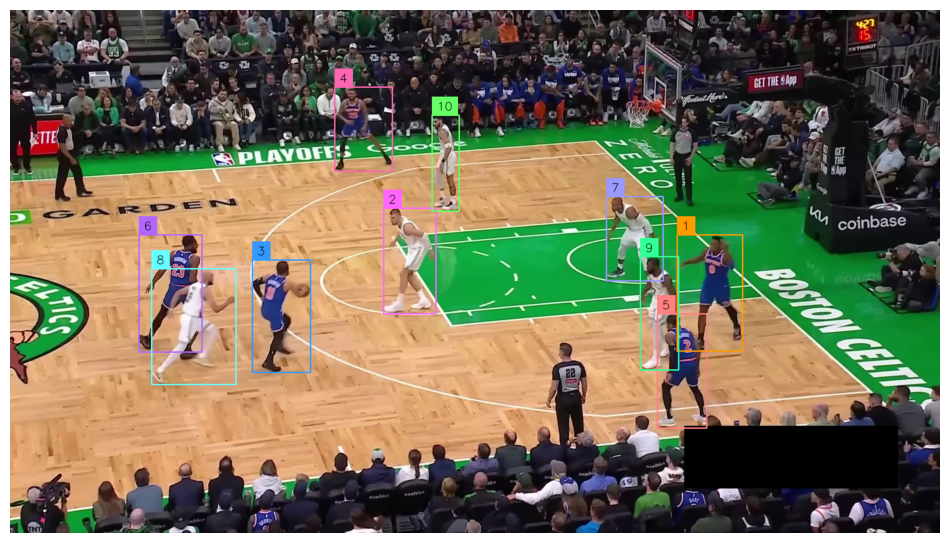

Processing video:   0%|          | 0/238 [00:00<?, ?it/s]

In [27]:
TARGET_VIDEO_PATH = HOME / f"{SOURCE_VIDEO_PATH.stem}-mask{SOURCE_VIDEO_PATH.suffix}"
TARGET_VIDEO_COMPRESSED_PATH = HOME / f"{TARGET_VIDEO_PATH.stem}-compressed{TARGET_VIDEO_PATH.suffix}"

# define team annotators

mask_annotator = sv.MaskAnnotator(
    color=COLOR,
    color_lookup=sv.ColorLookup.TRACK,
    opacity=0.5)
box_annotator = sv.BoxAnnotator(
    color=COLOR,
    color_lookup=sv.ColorLookup.TRACK,
    thickness=2
)
id_annotator = sv.LabelAnnotator(
    color=COLOR,
    color_lookup=sv.ColorLookup.TRACK,
    text_color=sv.Color.BLACK,
    text_scale=0.8
)

# we use RF-DETR model to aquire future SAM2 prompt

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
detections = sv.Detections.from_inference(result)
detections = detections[np.isin(detections.class_id, PLAYER_CLASS_IDS)]
detections.tracker_id = np.arange(1, len(detections.class_id) + 1)

annotated_frame = frame.copy()
annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections)
annotated_frame = id_annotator.annotate(scene=annotated_frame, detections=detections, labels=detections.tracker_id)


sv.plot_image(annotated_frame)

# we prompt SAM2 using RF-DETR model detections

tracker = SAM2Tracker(predictor)
tracker.prompt_first_frame(frame, detections)

# we propagate tacks across all video frames

def callback(frame: np.ndarray, index: int) -> np.ndarray:
    detections = tracker.propagate(frame)
    annotated_frame = frame.copy()
    annotated_frame = mask_annotator.annotate(scene=annotated_frame, detections=detections)
    annotated_frame = box_annotator.annotate(scene=annotated_frame, detections=detections)
    annotated_frame = id_annotator.annotate(scene=annotated_frame, detections=detections, labels=detections.tracker_id)
    return annotated_frame

sv.process_video(
    source_path=SOURCE_VIDEO_PATH,
    target_path=TARGET_VIDEO_PATH,
    callback=callback,
    show_progress=True
)

!ffmpeg -y -loglevel error -i {TARGET_VIDEO_PATH} -vcodec libx264 -crf 28 {TARGET_VIDEO_COMPRESSED_PATH}


### Train and test clustering model

We are computing SigLIP embeddings for crops, reducing with UMAP, and fitting K-means. A quick validation confirms separation by uniform appearance.

In [17]:
team_classifier = TeamClassifier(device="cuda")
team_classifier.fit(crops)

Embedding extraction: 5it [00:00,  5.34it/s]


### Number recognition model

In [18]:
NUMBER_RECOGNITION_MODEL_ID = "basketball-jersey-numbers-ocr/7"
NUMBER_RECOGNITION_MODEL = get_model(model_id=NUMBER_RECOGNITION_MODEL_ID)
NUMBER_RECOGNITION_MODEL_PROMPT = "Read the number."

In [19]:
def coords_above_threshold(
    matrix: np.ndarray, threshold: float, sort_desc: bool = True
) -> List[Tuple[int, int]]:
    """
    Return all (row_index, col_index) where value > threshold.
    Rows and columns may repeat.
    Optionally sort by value descending.
    """
    A = np.asarray(matrix)
    rows, cols = np.where(A > threshold)
    pairs = list(zip(rows.tolist(), cols.tolist()))
    if sort_desc:
        pairs.sort(key=lambda rc: A[rc[0], rc[1]], reverse=True)
    return pairs


def match_detector_to_tracker_id(
    event_detections: sv.Detections,
    player_detections: sv.Detections,
    iou_threshold: float = 0.3,
) -> Optional[int]:
    """Map the best detector box for an event class to a SAM2 tracker_id."""
    if len(event_detections) == 0 or len(player_detections) == 0:
        return None

    best_idx = int(np.argmax(event_detections.confidence))
    event_box = event_detections.xyxy[best_idx:best_idx + 1]

    ious = sv.box_iou_batch(player_detections.xyxy, event_box).reshape(-1)
    matched_idx = int(np.argmax(ious))

    if ious[matched_idx] >= iou_threshold:
        return int(player_detections.tracker_id[matched_idx])
    return None

## Check number recognition model

### Frame by frame check

0it [00:00, ?it/s]FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.


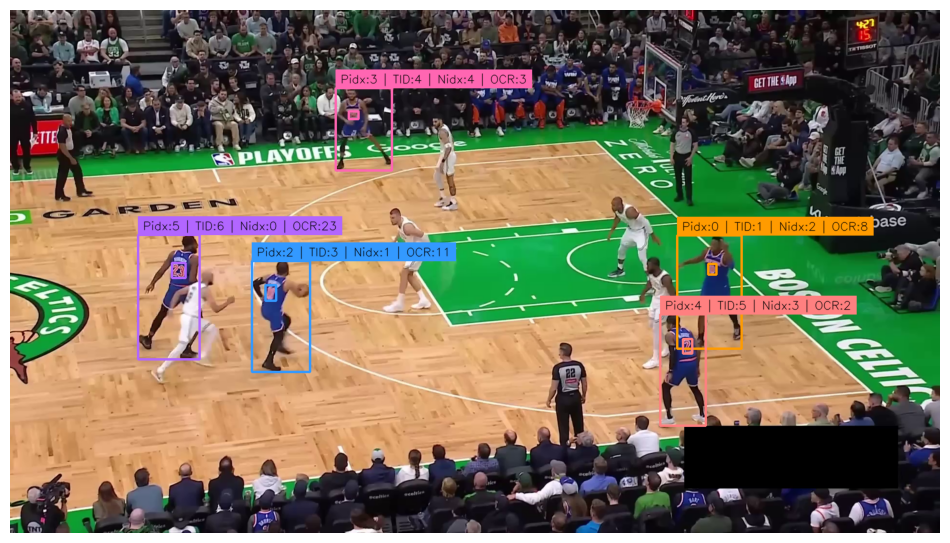

2it [00:19,  9.52s/it]


In [22]:
import pandas as pd

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)
NUMBER_CLASS_ID = 2

# define team annotators
box_annotator = sv.BoxAnnotator(color=COLOR, thickness=4, color_lookup=sv.ColorLookup.TRACK)
player_mask_annotator = sv.MaskAnnotator(color=COLOR.by_idx(3), opacity=0.8, color_lookup=sv.ColorLookup.INDEX)
number_mask_annotator = sv.MaskAnnotator(color=COLOR.by_idx(0), opacity=0.8, color_lookup=sv.ColorLookup.INDEX)
label_annotator = sv.LabelAnnotator(
    color=COLOR,
    color_lookup=sv.ColorLookup.TRACK,
    text_color=sv.Color.BLACK,
    text_scale=0.8)

# we use RF-DETR model to aquire future SAM2 prompt

result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
detections = sv.Detections.from_inference(result)
detections = detections[np.isin(detections.class_id, PLAYER_CLASS_IDS)]
detections.tracker_id = np.arange(1, len(detections.class_id) + 1)

# we prompt SAM2 using RF-DETR model detections

tracker = SAM2Tracker(predictor)
tracker.prompt_first_frame(frame, detections)

# We propagate tacks across all video frames
frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

# We initialize rows of df to monitor predictions
rows = []

for index, frame in tqdm(enumerate(frame_generator)):
    player_detections = tracker.propagate(frame)

    if index > 1:
      break

    if index % 5 == 0:
      frame_h, frame_w, *_ = frame.shape

      # we use RF-DETR model to detect numbers

      result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
      number_detections = sv.Detections.from_inference(result)
      number_detections = number_detections[number_detections.class_id == NUMBER_CLASS_ID]
      number_detections.mask = sv.xyxy_to_mask(boxes=number_detections.xyxy, resolution_wh=(frame_w, frame_h))

      # we crop out numbers detection and run recognition model
      number_crops = [
          sv.crop_image(frame, xyxy)
          for xyxy
          in sv.clip_boxes(sv.pad_boxes(xyxy=number_detections.xyxy, px=10, py=10), (frame_w, frame_h))
      ]
      number_results = [
          NUMBER_RECOGNITION_MODEL.infer(number_crop, prompt=NUMBER_RECOGNITION_MODEL_PROMPT)[0]
          for number_crop
          in number_crops
      ]
      all_recognized_numbers = [
          result.response.strip()
          for result in number_results
      ]

      # we use mask IoS to match numbers with players

      iou = sv.mask_iou_batch(
          masks_true=player_detections.mask,
          masks_detection=number_detections.mask,
          overlap_metric=sv.OverlapMetric.IOS
      )

      pairs = coords_above_threshold(iou, 0.9)

      # Initialize filtered detections and labels for annotation
      filtered_player_detections_for_annotation = sv.Detections.empty()
      numbers_for_annotation = []
      filtered_number_detections_for_annotation = sv.Detections.empty()

      # if pairs:
      #     player_idx, number_idx = zip(*pairs)

      #     # Filter player detections that have a matched number
      #     filtered_player_detections_for_annotation = player_detections[np.array(player_idx)]

      #     # Filter number detections that have a matched player and assign tracker_id
      #     filtered_number_detections_for_annotation = number_detections[np.array(number_idx)]
      #     filtered_number_detections_for_annotation.tracker_id = filtered_player_detections_for_annotation.tracker_id

      #     # Create labels for annotation using the recognized numbers corresponding to matched number_idx
      #     numbers_for_annotation = [all_recognized_numbers[idx] for idx in number_idx]
      if pairs:
        player_idx, number_idx = zip(*pairs)
        player_idx = np.asarray(player_idx, dtype=int)
        number_idx = np.asarray(number_idx, dtype=int)

        # Annotation stuff
        filtered_player_detections_for_annotation = (
            player_detections[player_idx]
        )
        filtered_number_detections_for_annotation = (
            number_detections[number_idx]
        )
        # Actual persistent SAM2 tracker IDs
        actual_tracker_ids = (
            player_detections.tracker_id[player_idx]
            .astype(int)
        )
        # Give number boxes the same tracker IDs as their matched players
        filtered_number_detections_for_annotation.tracker_id = (
            actual_tracker_ids
        )

        # Detailed labels displayed on player boxes
        numbers_for_annotation = [
            (
                f"Pidx:{p_idx} | "
                f"TID:{tracker_id} | "
                f"Nidx:{n_idx} | "
                f"OCR:{all_recognized_numbers[n_idx]}"
            )
            for p_idx, tracker_id, n_idx in zip(
                player_idx,
                actual_tracker_ids,
                number_idx
            )
        ]


      # we visualize all the masks

      # annotated_frame = frame.copy()
      # annotated_frame = player_mask_annotator.annotate(
      #     scene=annotated_frame,
      #     detections=player_detections)
      # annotated_frame = number_mask_annotator.annotate(
      #     scene=annotated_frame,
      #     detections=number_detections)
      # sv.plot_image(annotated_frame)

      # we visualize only matched pairs

      annotated_frame = frame.copy()
      annotated_frame = box_annotator.annotate(
          scene=annotated_frame,
          detections=filtered_player_detections_for_annotation)
      annotated_frame = box_annotator.annotate(
          scene=annotated_frame,
          detections=filtered_number_detections_for_annotation)
      annotated_frame = label_annotator.annotate(
          scene=annotated_frame,
          detections=filtered_player_detections_for_annotation,
          labels=numbers_for_annotation)

      sv.plot_image(annotated_frame)

      #print("Matched pairs (player_idx, number_idx):", pairs)

      matched_number_indices = {number_idx for _, number_idx in pairs}
      all_number_indices = set(range(len(number_detections)))
      unmatched_number_indices = all_number_indices - matched_number_indices

      # print("Matched number indices:", sorted(matched_number_indices))
      # print("Unmatched number indices:", sorted(unmatched_number_indices))
      pid_to_player = {
        0: ("Anunoby", 8),
        1: ("Porzingis", 8),
        2: ("Brunson", 11),
        3: ("Bridges", 25),
        4: ("McBride", 2),
        5: ("Robinson", 23),
        6: ("Horford", 42),
        7: ("White", 9),
        8: ("Brown", 7),
        9: ("Tatum", 0),
    }

      #print("\n--- Jersey OCR size diagnosis ---")
      for p_idx, idx in pairs:

        player_name, real_number = pid_to_player[p_idx]
        xyxy = number_detections.xyxy[idx]
        predicted = all_recognized_numbers[idx]

        rows.append(
            {
              "player_name": player_name,
              "real_number": real_number,
              "predicted_number": predicted,
              "height": xyxy[2]-xyxy[0],
              "width": xyxy[3]-xyxy[1],
              "area": (xyxy[2]-xyxy[0]) * (xyxy[3]-xyxy[1]),
              "frame": index,
            }
          )

df = pd.DataFrame(rows)

        # print(
        #     f"{player_name}, "
        #     f"confidence={number_detections.confidence[idx]:.3f}, "
        #     f"box={xyxy}, "
        #     f"OCR={predicted}, "
        #     f"real={real_number}, "
        #     f"w={diagnosis.width:.1f}, h={diagnosis.height:.1f}, "
        #     f"area={diagnosis.area:.0f}, "
        #     f"too_small={diagnosis.too_small}"
        # )
        # print(f"  -> {diagnosis.reason}")
        # print("----------------------------------------------------")

## Player recognition

Since we do not control which IDs the clustering algorithm assigns to the teams, after training and testing we must select one of the dictionaries below.

Embedding extraction: 0it [00:00, ?it/s]

Embedding extraction: 5it [00:30,  6.16s/it]


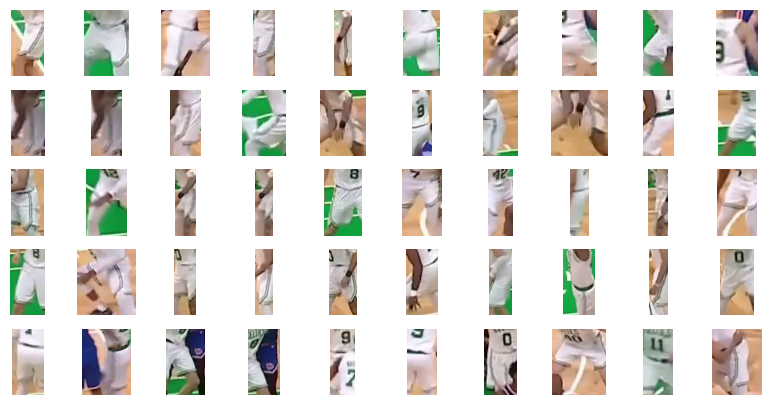

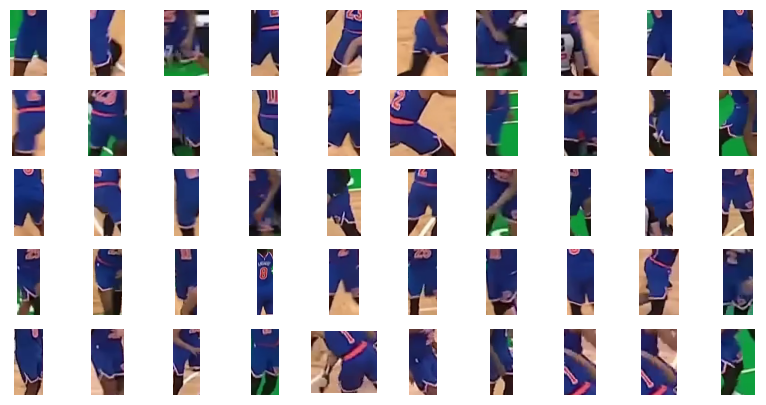

In [20]:
teams = team_classifier.predict(crops)

team_0 = [crop for crop, team in zip(crops, teams) if team == 0]
team_1 = [crop for crop, team in zip(crops, teams) if team == 1]

sv.plot_images_grid(
    images=team_0[:50],
    grid_size=(5, 10),
    size=(10, 5)
)

sv.plot_images_grid(
    images=team_1[:50],
    grid_size=(5, 10),
    size=(10, 5)
)

In [30]:
# TEAM_NAMES = {
#     0: "New York Knicks",
#     1: "Boston Celtics",
# }
TEAM_NAMES = {
    0: "Boston Celtics",
    1: "New York Knicks",
}

#### Beta with ball handler

In [22]:
def match_detector_to_tracker_id(
    event_detections: sv.Detections,
    player_detections: sv.Detections,
    iou_threshold: float = 0.3,
) -> int | None:
    """Map the best detector box for an event class to a SAM2 tracker_id."""
    if len(event_detections) == 0 or len(player_detections) == 0:
        return None

    best_idx = int(np.argmax(event_detections.confidence))
    event_box = event_detections.xyxy[best_idx:best_idx + 1]

    ious = sv.box_iou_batch(player_detections.xyxy, event_box).reshape(-1)
    matched_idx = int(np.argmax(ious))

    if ious[matched_idx] >= iou_threshold:
        return int(player_detections.tracker_id[matched_idx])
    return None

In [23]:
#SOURCE_VIDEO_PATH = SOURCE_VIDEO_DIRECTORY / "boston-celtics-new-york-knicks-game-1-q1-0.16-03.11.mp4"

frames_history = []
player_detections_history = []
state_detections_history = []
other_detections_history = []

validated_numbers = set()
NUMBER_CLASS_ID = 2
OTHER_CLASS_IDS = [0, 1, 9] # ball, ball-in-rim, player, player-in-possession, player-jump-shot, player-layup-dunk, player-shot-block, rim

number_validator = ConsecutiveValueTracker(n_consecutive=3)
team_validator = ConsecutiveValueTracker(n_consecutive=1)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

# we use RF-DETR model to aquire future SAM2 prompt

result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
detections = sv.Detections.from_inference(result)
detections = detections[np.isin(detections.class_id, PLAYER_CLASS_IDS)]
detections.tracker_id = np.arange(1, len(detections.class_id) + 1)

# we determine the team for each player and assign a team ID to every detection

boxes = sv.scale_boxes(xyxy=detections.xyxy, factor=0.4)
crops = [sv.crop_image(frame, box) for box in boxes]
TEAMS = np.array(team_classifier.predict(crops))

team_validator.update(tracker_ids=detections.tracker_id, values=TEAMS)

# we prompt SAM2 using RF-DETR model detections

tracker = SAM2Tracker(predictor)
tracker.prompt_first_frame(frame, detections)

# we propagate tracks across all video frames

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

for index, frame in tqdm(enumerate(frame_generator)):
    player_detections = tracker.propagate(frame)
    frames_history.append(frame)
    player_detections_history.append(player_detections)

    # Ball handling tracking every frame
    result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
    all_detections = sv.Detections.from_inference(result)
    state_detections = all_detections[np.isin(all_detections.class_id, PLAYER_CLASS_IDS)]

    other_detections = all_detections[np.isin(all_detections.class_id, OTHER_CLASS_IDS)]

    # Clean duplicate player-state boxes
    state_detections = state_detections.with_nms(threshold=0.5,class_agnostic=True)
    state_detections_history.append(state_detections)
    other_detections_history.append(other_detections)
    # we perform number recognition at specific frame intervals
    unresolved = [
        tracker_id
        for tracker_id in player_detections.tracker_id
        if int(tracker_id) not in validated_numbers
    ]
    if index % 5 == 0 and unresolved:
        # print(index)
        frame_h, frame_w, *_ = frame.shape

        # we use RF-DETR model to detect numbers on player

        result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
        number_detections = sv.Detections.from_inference(result)
        number_detections = number_detections[number_detections.class_id == NUMBER_CLASS_ID]
        number_detections.mask = sv.xyxy_to_mask(boxes=number_detections.xyxy, resolution_wh=(frame_w, frame_h))

        # we crop out numbers detection and run recognition model

        number_crops = [
            sv.crop_image(frame, xyxy)
            for xyxy
            in sv.clip_boxes(sv.pad_boxes(xyxy=number_detections.xyxy, px=10, py=10), (frame_w, frame_h))
        ]
        number_results = [
            NUMBER_RECOGNITION_MODEL.infer(number_crop, prompt=NUMBER_RECOGNITION_MODEL_PROMPT)[0]
            for number_crop
            in number_crops
        ]

        numbers = [
            result.response.strip()
            for result in number_results
        ]

        # we use mask IoS to match numbers with players

        iou = sv.mask_iou_batch(
            masks_true=player_detections.mask,
            masks_detection=number_detections.mask,
            overlap_metric=sv.OverlapMetric.IOS
        )

        pairs = coords_above_threshold(iou, 0.9)

        if pairs:
            player_idx, number_idx = zip(*pairs)
            tracker_ids = player_detections.tracker_id[list(player_idx)]
            number_idx = list(number_idx)

            # we update number_validator state
            numbers = [numbers[int(i)] for i in number_idx]
            number_validator.update(tracker_ids, values=numbers)
            validated_numbers.update(tracker_ids.tolist()) # Added tracker_ids to the set


Embedding extraction: 1it [00:02,  2.60s/it]


0it [00:00, ?it/s]FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
238it [07:20,  1.85s/it]


In [24]:
def get_state_matches(
    player_detections,
    state_detections,
    iou_threshold=0.3
):
    """
    Match RF-DETR player-state detections to SAM2 tracked
    players using bounding-box IoU.

    Returns:
        Dictionary:
            tracking_id -> set of RF-DETR class IDs
    """

    matches = {}

    if (
        len(player_detections) == 0
        or len(state_detections) == 0
        or player_detections.tracker_id is None
    ):
        return matches

    iou_matrix = sv.box_iou_batch(
        player_detections.xyxy,
        state_detections.xyxy
    )

    for player_idx, tracker_id in enumerate(
        player_detections.tracker_id
    ):

        tracker_id = int(tracker_id)

        # RF-DETR detections overlapping this tracked player
        state_indices = np.where(
            iou_matrix[player_idx] >= iou_threshold
        )[0]

        matches[tracker_id] = {
            int(state_detections.class_id[i])
            for i in state_indices
        }

    return matches

In [37]:
TARGET_VIDEO_PATH = HOME / (
    f"{SOURCE_VIDEO_PATH.stem}-result{SOURCE_VIDEO_PATH.suffix}"
)

TARGET_VIDEO_COMPRESSED_PATH = HOME / (
    f"{TARGET_VIDEO_PATH.stem}-compressed{TARGET_VIDEO_PATH.suffix}"
)

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)

# Team annotators
team_colors = sv.ColorPalette.from_hex([
    TEAM_COLORS[TEAM_NAMES[0]],
    TEAM_COLORS[TEAM_NAMES[1]],
])

team_mask_annotator = sv.MaskAnnotator(
    color=team_colors,
    opacity=0.5,
    color_lookup=sv.ColorLookup.INDEX,
)

team_label_annotator = sv.RichLabelAnnotator(
    font_path=f"{HOME}/fonts/Staatliches-Regular.ttf",
    font_size=40,
    color=team_colors,
    text_color=sv.Color.WHITE,
    text_position=sv.Position.BOTTOM_CENTER,
    text_offset=(0, 10),
    color_lookup=sv.ColorLookup.INDEX,
)

# Ball-handler annotators
handler_color = sv.ColorPalette.from_hex(["#FFD700"])

handler_box_annotator = sv.BoxAnnotator(
    color=handler_color,
    thickness=6,
)

handler_label_annotator = sv.RichLabelAnnotator(
    font_path=f"{HOME}/fonts/Staatliches-Regular.ttf",
    font_size=32,
    color=handler_color,
    text_color=sv.Color.BLACK,
    text_position=sv.Position.TOP_CENTER,
    text_offset=(0, -10),
)

with sv.VideoSink(TARGET_VIDEO_PATH, video_info) as sink:
    for frame, player_detections, state_detections in tqdm(zip(frames_history, player_detections_history, state_detections_history)):
        player_detections = player_detections[player_detections.area > 100]
        handler_detections = state_detections[np.isin(state_detections.class_id, 4)]
        handler_detections = handler_detections[handler_detections.area > 100]

        teams = team_validator.get_validated(tracker_ids=player_detections.tracker_id)
        teams = np.array(teams).astype(int)
        numbers = number_validator.get_validated(tracker_ids=player_detections.tracker_id)
        numbers = np.array(numbers)

        labels = [
            f"#{number} {TEAM_ROSTERS[TEAM_NAMES[team]].get(number)}"
            for number, team
            in zip(numbers, teams)
        ]

        annotated_frame = frame.copy()
        annotated_frame = team_mask_annotator.annotate(
            scene=annotated_frame,
            detections=player_detections,
            custom_color_lookup=teams)

        annotated_frame = team_label_annotator.annotate(
            scene=annotated_frame,
            detections=player_detections,
            labels=labels,
            custom_color_lookup=teams)
        
        if len(handler_detections) > 0:
            annotated_frame = handler_box_annotator.annotate(
            scene=annotated_frame,
            detections=handler_detections,
        )
            annotated_frame = handler_label_annotator.annotate(
                scene=annotated_frame,
                detections=handler_detections,
                labels=["BALL_HANDLER"])

        sink.write_frame(annotated_frame)


!ffmpeg -y -loglevel error \
    -i "{TARGET_VIDEO_PATH}" \
    -vcodec libx264 \
    -crf 28 \
    "{TARGET_VIDEO_COMPRESSED_PATH}"

print(TARGET_VIDEO_COMPRESSED_PATH)

[2026-08-15 12:31:28] [WARNING] supervision.annotators.core - Font path '/workspace/fonts/Staatliches-Regular.ttf' not found. Using PIL's default font.
[2026-08-15 12:31:28] [WARNING] supervision.annotators.core - Font path '/workspace/fonts/Staatliches-Regular.ttf' not found. Using PIL's default font.
5it [00:00,  8.20it/s]

238it [00:24,  9.65it/s]


/workspace/boston-celtics-new-york-knicks-game-1-q1-04.28-04.20-result-compressed.mp4


In [46]:
TARGET_VIDEO_PATH = HOME / (
    f"{SOURCE_VIDEO_PATH.stem}-result{SOURCE_VIDEO_PATH.suffix}"
)

TARGET_VIDEO_COMPRESSED_PATH = HOME / (
    f"{TARGET_VIDEO_PATH.stem}-compressed{TARGET_VIDEO_PATH.suffix}"
)

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)

# Team annotators
team_colors = sv.ColorPalette.from_hex([
    TEAM_COLORS[TEAM_NAMES[0]],
    TEAM_COLORS[TEAM_NAMES[1]],
])

team_mask_annotator = sv.MaskAnnotator(
    color=team_colors,
    opacity=0.5,
    color_lookup=sv.ColorLookup.INDEX,
)

team_label_annotator = sv.RichLabelAnnotator(
    font_path=f"{HOME}/fonts/Staatliches-Regular.ttf",
    font_size=40,
    color=team_colors,
    text_color=sv.Color.WHITE,
    text_position=sv.Position.BOTTOM_CENTER,
    text_offset=(0, 10),
    color_lookup=sv.ColorLookup.INDEX,
)

# Ball-handler annotators
handler_color = sv.ColorPalette.from_hex(["#FFD700"])

handler_box_annotator = sv.BoxAnnotator(
    color=handler_color,
    thickness=6,
)

handler_label_annotator = sv.RichLabelAnnotator(
    font_path=f"{HOME}/fonts/Staatliches-Regular.ttf",
    font_size=32,
    color=handler_color,
    text_color=sv.Color.BLACK,
    text_position=sv.Position.TOP_CENTER,
    text_offset=(0, -10),
)

with sv.VideoSink(TARGET_VIDEO_PATH, video_info) as sink:
    for frame, player_detections, state_detections in tqdm(zip(frames_history, player_detections_history, state_detections_history)):
        player_detections = player_detections[player_detections.area > 100]

        teams = team_validator.get_validated(tracker_ids=player_detections.tracker_id)
        teams = np.array(teams).astype(int)
        numbers = number_validator.get_validated(tracker_ids=player_detections.tracker_id)
        numbers = np.array(numbers)

        # labels = [
        #     f"#{number} {TEAM_ROSTERS[TEAM_NAMES[team]].get(number)}"
        #     for number, team
        #     in zip(numbers, teams)
        # ]

        # Clean duplicate player-state boxes
        state_detections = state_detections.with_nms(threshold=0.5,class_agnostic=True)

        # Find possession detection
        handler_detections = state_detections[state_detections.class_id == PLAYER_CLASS_IDS[1]]
        print(handler_detections.confidence)

        ball_handler_id = None

        if len(handler_detections) > 0 and len(player_detections) > 0:
            # Use the most confident possession detection
            best_idx = np.argmax(handler_detections.confidence)
            possession_box = handler_detections.xyxy[best_idx:best_idx + 1]

            # Match it to the tracked SAM2 player
            ious = sv.box_iou_batch(player_detections.xyxy,possession_box).reshape(-1)

            matched_idx = int(np.argmax(ious))

            if ious[matched_idx] >= 0.3:ball_handler_id = int(player_detections.tracker_id[matched_idx])
            
            labels = [
                f"#{number} {TEAM_ROSTERS[TEAM_NAMES[team]].get(number)} | BALL HANDLER"
                if class_id == PLAYER_CLASS_IDS[1]
                else f"#{number} {TEAM_ROSTERS[TEAM_NAMES[team]].get(number)}"
                for number, team, tracker_id, class_id in zip(numbers, teams, player_detections.tracker_id, state_detections.class_id) 
            ]
        
        else:
            labels = [
                f"#{number} {TEAM_ROSTERS[TEAM_NAMES[team]].get(number)}"
                for number, team
                in zip(numbers, teams)
            ]

        # print("Tracked players:", len(player_detections))
        # print("Ball-handler ID:", ball_handler_id)

        # print(detections.class_id)
        # print(state_detections.class_id)

        annotated_frame = frame.copy()
        annotated_frame = team_mask_annotator.annotate(
            scene=annotated_frame,
            detections=player_detections,
            custom_color_lookup=teams)

        annotated_frame = team_label_annotator.annotate(
            scene=annotated_frame,
            detections=player_detections,
            labels=labels,
            custom_color_lookup=teams)
        
        # annotated_frame = handler_box_annotator.annotate(
        # scene=annotated_frame,
        # detections=handler_detections,
        # )
    
        # annotated_frame = handler_label_annotator.annotate(
        #     scene=annotated_frame,
        #     detections=handler_detections,
        #     labels=["BALL HANDLER"])

        sink.write_frame(annotated_frame)


!ffmpeg -y -loglevel error \
    -i "{TARGET_VIDEO_PATH}" \
    -vcodec libx264 \
    -crf 28 \
    "{TARGET_VIDEO_COMPRESSED_PATH}"

print(TARGET_VIDEO_COMPRESSED_PATH)

[2026-08-15 13:02:23] [WARNING] supervision.annotators.core - Font path '/workspace/fonts/Staatliches-Regular.ttf' not found. Using PIL's default font.
[2026-08-15 13:02:23] [WARNING] supervision.annotators.core - Font path '/workspace/fonts/Staatliches-Regular.ttf' not found. Using PIL's default font.
1it [00:00,  6.78it/s]

[0.93666524]
[0.93344915]


3it [00:00,  7.76it/s]

[0.9323346]
[]


5it [00:00,  8.21it/s]

...

43it [00:04, 10.23it/s]

[]
[]
[]


44it [00:04,  9.30it/s]


[]


KeyboardInterrupt: 

In [38]:
Video(TARGET_VIDEO_COMPRESSED_PATH, embed=True, width=720)

### Tracking table

In [47]:
import numpy as np
import pandas as pd
import supervision as sv


# ============================================================
# 1. BUILD PLAYER IDENTITY TABLE
# ============================================================

# Collect every unique tracker ID found during the video
all_tracker_ids = sorted({
    int(tracker_id)
    for detections in player_detections_history
    if detections.tracker_id is not None
    for tracker_id in detections.tracker_id
})

# Get validated team and jersey number
teams = team_validator.get_validated(
    tracker_ids=all_tracker_ids
)

numbers = number_validator.get_validated(
    tracker_ids=all_tracker_ids
)

identity_records = []

for tracker_id, team_value, number_value in zip(
    all_tracker_ids,
    teams,
    numbers
):

    # --------------------------------------------------------
    # Validated team
    # --------------------------------------------------------

    team_id = (
        int(team_value)
        if team_value is not None and not pd.isna(team_value)
        else None
    )

    team_name = (
        TEAM_NAMES[team_id]
        if team_id is not None
        else None
    )

    # --------------------------------------------------------
    # Validated jersey number
    # --------------------------------------------------------

    jersey_number = (
        str(number_value).strip()
        if number_value is not None and not pd.isna(number_value)
        else None
    )

    if jersey_number in {"", "None", "nan"}:
        jersey_number = None

    # --------------------------------------------------------
    # Match team + jersey number to roster
    # --------------------------------------------------------

    player_name = None

    if team_name is not None and jersey_number is not None:

        roster = TEAM_ROSTERS[team_name]

        # Try string key first
        player_name = roster.get(jersey_number)

        # Then integer key
        if player_name is None and jersey_number.isdigit():
            player_name = roster.get(int(jersey_number))

    identity_records.append({
        "tracking_id": tracker_id,
        "team_id": team_id,
        "team": team_name,
        "jersey_number": jersey_number,
        "player_name": player_name,
    })


identity_df = pd.DataFrame(identity_records)


# ============================================================
# 2. MATCH RF-DETR STATE DETECTIONS TO SAM2 TRACKS
# ============================================================

def get_state_matches(
    player_detections,
    state_detections,
    iou_threshold=0.3
):
    """
    Match RF-DETR player-state detections to SAM2 tracked
    players using bounding-box IoU.

    Returns:
        Dictionary:
            tracking_id -> set of RF-DETR class IDs
    """

    matches = {}

    if (
        len(player_detections) == 0
        or len(state_detections) == 0
        or player_detections.tracker_id is None
    ):
        return matches

    iou_matrix = sv.box_iou_batch(
        player_detections.xyxy,
        state_detections.xyxy
    )

    for player_idx, tracker_id in enumerate(
        player_detections.tracker_id
    ):

        tracker_id = int(tracker_id)

        # RF-DETR detections overlapping this tracked player
        state_indices = np.where(
            iou_matrix[player_idx] >= iou_threshold
        )[0]

        matches[tracker_id] = {
            int(state_detections.class_id[i])
            for i in state_indices
        }

    return matches


# ============================================================
# 3. BUILD FRAME-LEVEL TRACKING TABLE
# ============================================================

tracking_records = []

for frame_idx, (
    player_detections,
    state_detections
) in enumerate(
    zip(
        player_detections_history,
        state_detections_history
    )
):

    # Match RF-DETR state detections to SAM2 tracks
    state_matches = get_state_matches(
        player_detections,
        state_detections,
        iou_threshold=0.3
    )

    if (
        player_detections.tracker_id is None
        or len(player_detections) == 0
    ):
        continue

    # --------------------------------------------------------
    # One row per tracked player
    # --------------------------------------------------------

    for player_idx, tracker_id in enumerate(
        player_detections.tracker_id
    ):

        tracker_id = int(tracker_id)

        x1, y1, x2, y2 = (
            player_detections.xyxy[player_idx]
        )

        classes = state_matches.get(
            tracker_id,
            set()
        )

        # ----------------------------------------------------
        # RF-DETR player states
        # ----------------------------------------------------

        in_possession = 4 in classes
        jump_shot = 5 in classes
        player_layup_dunk = 6 in classes

        tracking_records.append({
            "frame": frame_idx,
            "tracking_id": tracker_id,

            "x1": float(x1),
            "y1": float(y1),
            "x2": float(x2),
            "y2": float(y2),

            "jump_shot": bool(jump_shot),
            "in_possession": bool(in_possession),
            "player_layup_dunk": bool(
                player_layup_dunk
            ),
        })


tracking_df = pd.DataFrame(tracking_records)


# ============================================================
# 4. ADD PLAYER IDENTITY
# ============================================================

tracking_table = tracking_df.merge(
    identity_df,
    on="tracking_id",
    how="left"
)


# ============================================================
# 5. REORDER COLUMNS
# ============================================================

tracking_table = tracking_table[
    [
        "frame",
        "tracking_id",
        "player_name",
        "team",
        "jersey_number",

        "x1",
        "y1",
        "x2",
        "y2",

        "jump_shot",
        "in_possession",
        "player_layup_dunk",
    ]
]


# ============================================================
# 6. SORT
# ============================================================

tracking_table = tracking_table.sort_values(
    ["frame", "tracking_id"]
).reset_index(drop=True)


# ============================================================
# RESULT
# ============================================================

print(tracking_table.head(20))
print()
print(f"Rows: {len(tracking_table):,}")
print(f"Frames: {tracking_table['frame'].nunique():,}")
print(
    f"Players: "
    f"{tracking_table['tracking_id'].nunique():,}"
)

    frame  tracking_id player_name             team jersey_number      x1  \
0       0            1     Anunoby  New York Knicks             8  1377.0   
1       0            2   Porzingis   Boston Celtics             8   771.0   
2       0            3     Brunson  New York Knicks            11   499.0   
3       0            4     Bridges  New York Knicks            25   672.0   
4       0            5     McBride  New York Knicks             2  1342.0   
5       0            6    Robinson  New York Knicks            23   264.0   
6       0            7     Horford   Boston Celtics            42  1233.0   
7       0            8       White   Boston Celtics             9   293.0   
8       0            9       Brown   Boston Celtics             7  1299.0   
9       0           10        None   Boston Celtics          None   872.0   
10      1            1     Anunoby  New York Knicks             8  1366.0   
11      1            2   Porzingis   Boston Celtics             8   783.0   

In [44]:
handle_tracking_table = tracking_table[tracking_table['jump_shot'] == True]
handle_tracking_table.head(20)

,frame,tracking_id,player_name,team,jersey_number,x1,y1,x2,y2,confidence,jump_shot,in_possession,player_layup_dunk
1750,175,1,Anunoby,New York Knicks,8,808.0,615.0,913.0,985.0,None,True,False,False
1760,176,1,Anunoby,New York Knicks,8,807.0,600.0,910.0,984.0,None,True,False,False
1770,177,1,Anunoby,New York Knicks,8,806.0,586.0,907.0,975.0,None,True,False,False
1780,178,1,Anunoby,New York Knicks,8,805.0,568.0,904.0,961.0,None,True,False,False
1790,179,1,Anunoby,New York Knicks,8,804.0,555.0,901.0,954.0,None,True,False,False
1800,180,1,Anunoby,New York Knicks,8,804.0,525.0,898.0,947.0,None,True,False,False
1810,181,1,Anunoby,New York Knicks,8,804.0,494.0,898.0,942.0,None,True,False,False
1820,182,1,Anunoby,New York Knicks,8,801.0,460.0,907.0,938.0,None,True,False,False
1830,183,1,Anunoby,New York Knicks,8,798.0,541.0,889.0,936.0,None,True,False,False
1840,184,1,Anunoby,New York Knicks,8,796.0,536.0,896.0,935.0,None,True,False,False


#### Old version

In [ ]:
SOURCE_VIDEO_PATH = SOURCE_VIDEO_DIRECTORY / "boston-celtics-new-york-knicks-game-1-q1-03.16-03.11.mp4"

frames_history = []
detections_history = []
NUMBER_CLASS_ID = 2
PLAYER_CLASS_IDS = [3, 4, 5, 6, 7] # player, player-in-possession, player-jump-shot, player-layup-dunk, player-shot-block

number_validator = ConsecutiveValueTracker(n_consecutive=3)
team_validator = ConsecutiveValueTracker(n_consecutive=1)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

# we use RF-DETR model to aquire future SAM2 prompt

result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
detections = sv.Detections.from_inference(result)
detections = detections[np.isin(detections.class_id, PLAYER_CLASS_IDS)]
detections.tracker_id = np.arange(1, len(detections.class_id) + 1)

# we determine the team for each player and assign a team ID to every detection

boxes = sv.scale_boxes(xyxy=detections.xyxy, factor=0.4)
crops = [sv.crop_image(frame, box) for box in boxes]
TEAMS = np.array(team_classifier.predict(crops))

team_validator.update(tracker_ids=detections.tracker_id, values=TEAMS)

# we prompt SAM2 using RF-DETR model detections

tracker = SAM2Tracker(predictor)
tracker.prompt_first_frame(frame, detections)

# we propagate tracks across all video frames

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)

for index, frame in tqdm(enumerate(frame_generator)):
    player_detections = tracker.propagate(frame)
    frames_history.append(frame)
    detections_history.append(player_detections)

    # we perform number recognition at specific frame intervals
    if index % 5 == 0:
        # print(index)
        frame_h, frame_w, *_ = frame.shape

        # we use RF-DETR model to detect numbers on player

        result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
        number_detections = sv.Detections.from_inference(result)
        number_detections = number_detections[number_detections.class_id == NUMBER_CLASS_ID]
        number_detections.mask = sv.xyxy_to_mask(boxes=number_detections.xyxy, resolution_wh=(frame_w, frame_h))

        # we crop out numbers detection and run recognition model

        number_crops = [
            sv.crop_image(frame, xyxy)
            for xyxy
            in sv.clip_boxes(sv.pad_boxes(xyxy=number_detections.xyxy, px=10, py=10), (frame_w, frame_h))
        ]
        number_results = [
            NUMBER_RECOGNITION_MODEL.infer(number_crop, prompt=NUMBER_RECOGNITION_MODEL_PROMPT)[0]
            for number_crop
            in number_crops
        ]

        numbers = [
            result.response.strip()
            for result in number_results
        ]

        # we use mask IoS to match numbers with players

        iou = sv.mask_iou_batch(
            masks_true=player_detections.mask,
            masks_detection=number_detections.mask,
            overlap_metric=sv.OverlapMetric.IOS
        )

        pairs = coords_above_threshold(iou, 0.9)

        if pairs:
            player_idx, number_idx = zip(*pairs)
            player_idx = [i + 1 for i in player_idx]
            number_idx = list(number_idx)

            # we update number_validator state

            numbers = [numbers[int(i)] for i in number_idx]
            number_validator.update(tracker_ids=player_idx, values=numbers)

In [ ]:
TARGET_VIDEO_PATH = HOME / f"{SOURCE_VIDEO_PATH.stem}-result{SOURCE_VIDEO_PATH.suffix}"
TARGET_VIDEO_COMPRESSED_PATH = HOME / f"{TARGET_VIDEO_PATH.stem}-compressed{TARGET_VIDEO_PATH.suffix}"

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)

team_colors = sv.ColorPalette.from_hex([
    TEAM_COLORS[TEAM_NAMES[0]],
    TEAM_COLORS[TEAM_NAMES[1]]
])

team_mask_annotator = sv.MaskAnnotator(
    color=team_colors,
    opacity=0.5,
    color_lookup=sv.ColorLookup.INDEX)
team_label_annotator = sv.RichLabelAnnotator(
    font_path=f"{HOME}/fonts/Staatliches-Regular.ttf",
    font_size=40,
    color=team_colors,
    text_color=sv.Color.WHITE,
    text_position=sv.Position.BOTTOM_CENTER,
    text_offset=(0, 10),
    color_lookup=sv.ColorLookup.INDEX)
label_annotator = sv.LabelAnnotator(
    color=team_colors,
    text_color=sv.Color.BLACK,
    color_lookup=sv.ColorLookup.INDEX
)

with sv.VideoSink(TARGET_VIDEO_PATH, video_info) as sink:
    for frame, detections in tqdm(zip(frames_history, detections_history)):
        detections = detections[detections.area > 100]

        teams = team_validator.get_validated(tracker_ids=detections.tracker_id)
        teams = np.array(teams).astype(int)
        numbers = number_validator.get_validated(tracker_ids=detections.tracker_id)
        numbers = np.array(numbers)

        labels = [
            f"#{number} {TEAM_ROSTERS[TEAM_NAMES[team]].get(number)}"
            for number, team
            in zip(numbers, teams)
        ]

        annotated_frame = frame.copy()
        annotated_frame = team_mask_annotator.annotate(
            scene=annotated_frame,
            detections=detections,
            custom_color_lookup=teams)
        annotated_frame = team_label_annotator.annotate(
            scene=annotated_frame,
            detections=detections,
            labels=labels,
            custom_color_lookup=teams)

        sink.write_frame(annotated_frame)

!ffmpeg -y -loglevel error -i {TARGET_VIDEO_PATH} -vcodec libx264 -crf 28 {TARGET_VIDEO_COMPRESSED_PATH}

In [ ]:
import numpy as np
import pandas as pd

# Collect every unique tracker ID found during the video
all_tracker_ids = sorted({
    int(tracker_id)
    for detections in detections_history
    if detections.tracker_id is not None
    for tracker_id in detections.tracker_id
})

teams = team_validator.get_validated(
    tracker_ids=all_tracker_ids
)

numbers = number_validator.get_validated(
    tracker_ids=all_tracker_ids
)

identity_records = []

for tracker_id, team_value, number_value in zip(
    all_tracker_ids,
    teams,
    numbers
):
    # Validated team
    team_id = (
        int(team_value)
        if team_value is not None and not pd.isna(team_value)
        else None
    )

    team_name = (
        TEAM_NAMES[team_id]
        if team_id is not None
        else None
    )

    # Validated jersey number
    jersey_number = (
        str(number_value).strip()
        if number_value is not None and not pd.isna(number_value)
        else None
    )

    if jersey_number in {"", "None", "nan"}:
        jersey_number = None

    # Match team and jersey number to roster
    player_name = None

    if team_name is not None and jersey_number is not None:
        roster = TEAM_ROSTERS[team_name]

        # Try string key first
        player_name = roster.get(jersey_number)

        # Then integer key, if necessary
        if player_name is None and jersey_number.isdigit():
            player_name = roster.get(int(jersey_number))

    identity_records.append({
        "tracker_id": tracker_id,
        "team_id": team_id,
        "team_name": team_name,
        "jersey_number": jersey_number,
        "player_name": player_name,
    })

identity_df = pd.DataFrame(identity_records)

identity_df

In [ ]:
Video(TARGET_VIDEO_COMPRESSED_PATH, embed=True, width=720)

## Ball handler ID

In [ ]:
PLAYER_CLASS_IDS = [3, 4, 5, 6, 7] # player, player-in-possession, player-jump-shot, player-layup-dunk, player-shot-block

team_validator = ConsecutiveValueTracker(n_consecutive=1)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

# we use RF-DETR model to aquire future SAM2 prompt

result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
detections = sv.Detections.from_inference(result)
detections = detections[np.isin(detections.class_id, PLAYER_CLASS_IDS)]
detections.tracker_id = np.arange(1, len(detections.class_id) + 1)

# we determine the team for each player and assign a team ID to every detection

boxes = sv.scale_boxes(xyxy=detections.xyxy, factor=0.4)
crops = [sv.crop_image(frame, box) for box in boxes]
TEAMS = np.array(team_classifier.predict(crops))

team_validator.update(tracker_ids=detections.tracker_id, values=TEAMS)

# we prompt SAM2 using RF-DETR model detections

tracker = SAM2Tracker(predictor)
tracker.prompt_first_frame(frame, detections)

# define annotators

team_colors = sv.ColorPalette.from_hex([
    TEAM_COLORS[TEAM_NAMES[0]],
    TEAM_COLORS[TEAM_NAMES[1]]
])

team_box_annotator = sv.BoxAnnotator(
    color=team_colors,
    thickness=2,
    color_lookup=sv.ColorLookup.INDEX
)

label_annotator = sv.LabelAnnotator(
    color=team_colors,
    text_color=sv.Color.WHITE,
    color_lookup=sv.ColorLookup.INDEX
)

# we propagate tracks across all video frames

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)


for index, frame in tqdm(enumerate(frame_generator)):
    if index >= 30:
      break

    player_detections = tracker.propagate(frame)

    # we use RF-DETR model to detect ball handler
    result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
    state_detections = sv.Detections.from_inference(result)
    state_detections = state_detections[np.isin(state_detections.class_id, PLAYER_CLASS_IDS)]

    # Clean duplicate player-state boxes
    state_detections = state_detections.with_nms(threshold=0.5,class_agnostic=True)

    # Find possession detection
    possession_detections = state_detections[state_detections.class_id == PLAYER_CLASS_IDS[1]]

    ball_handler_id = None

    if len(possession_detections) > 0 and len(player_detections) > 0:
        # Use the most confident possession detection
        best_idx = np.argmax(possession_detections.confidence)
        possession_box = possession_detections.xyxy[best_idx:best_idx + 1]

        # Match it to the tracked SAM2 player
        ious = sv.box_iou_batch(player_detections.xyxy,possession_box).reshape(-1)

        matched_idx = int(np.argmax(ious))

        if ious[matched_idx] >= 0.3:ball_handler_id = int(player_detections.tracker_id[matched_idx])

    print("Tracked players:", len(player_detections))
    print("Ball-handler ID:", ball_handler_id)

    labels = [
        f"ID {tracker_id} | BALL HANDLER"
        if class_id == PLAYER_CLASS_IDS[1]
        else f"ID {tracker_id}"
        for tracker_id, class_id in zip(
            player_detections.tracker_id,
            detections.class_id
        )
    ]

    team_ids = TEAMS[player_detections.tracker_id - 1]

    annotated_frame = frame.copy()

    annotated_frame = team_box_annotator.annotate(
        scene=annotated_frame,
        detections=player_detections,
        custom_color_lookup=TEAMS
    )

    annotated_frame = label_annotator.annotate(
        scene=annotated_frame,
        detections=player_detections,
        labels=labels,
        custom_color_lookup=TEAMS
    )

    sv.plot_image(annotated_frame)


In [ ]:
print(detections.class_id)

## Court keypoints detection

### Load keypoint detection model

In [21]:
KEYPOINT_DETECTION_MODEL_ID = "basketball-court-detection-2/14"
KEYPOINT_DETECTION_MODEL_CONFIDENCE = 0.3
KEYPOINT_DETECTION_MODEL_ANCHOR_CONFIDENCE = 0.5
KEYPOINT_DETECTION_MODEL = get_model(model_id=KEYPOINT_DETECTION_MODEL_ID)
KEYPOINT_COLOR = sv.Color.from_hex('#FF1493')

### Single frame keypoint detection




In [ ]:
vertex_annotator = sv.VertexAnnotator(color=KEYPOINT_COLOR, radius=8)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

result = KEYPOINT_DETECTION_MODEL.infer(frame, confidence=KEYPOINT_DETECTION_MODEL_CONFIDENCE)[0]
key_points = sv.KeyPoints.from_inference(result)

annotated_frame = frame.copy()
annotated_frame = vertex_annotator.annotate(
    scene=annotated_frame,
    key_points=key_points)

sv.plot_image(annotated_frame)

### Detecting keypoints with high confidence

In [ ]:
vertex_annotator = sv.VertexAnnotator(color=KEYPOINT_COLOR, radius=8)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

result = KEYPOINT_DETECTION_MODEL.infer(frame, confidence=KEYPOINT_DETECTION_MODEL_CONFIDENCE)[0]
key_points = sv.KeyPoints.from_inference(result)
key_points = key_points[:, key_points.keypoint_confidence[0] > KEYPOINT_DETECTION_MODEL_ANCHOR_CONFIDENCE]

annotated_frame = frame.copy()
annotated_frame = vertex_annotator.annotate(
    scene=annotated_frame,
    key_points=key_points)

sv.plot_image(annotated_frame)

## Map player positions to court coordinates

### Single frame player position mapping

In [ ]:
config = CourtConfiguration(league=League.NBA, measurement_unit=MeasurementUnit.FEET)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

# define team annotators

team_colors = sv.ColorPalette.from_hex([
    TEAM_COLORS[TEAM_NAMES[0]],
    TEAM_COLORS[TEAM_NAMES[1]]
])

team_box_annotator = sv.BoxAnnotator(
    color=team_colors,
    thickness=2,
    color_lookup=sv.ColorLookup.INDEX
)

# we use RF-DETR model to aquire future SAM2 prompt

result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
detections = sv.Detections.from_inference(result)
detections = detections[np.isin(detections.class_id, PLAYER_CLASS_IDS)]
detections.tracker_id = np.arange(1, len(detections.class_id) + 1)

ball_handler_mask = (
    detections.class_id == PLAYER_CLASS_IDS[1]
)

ball_handler_ids = detections.tracker_id[ball_handler_mask]

ball_handler_id = (
    int(ball_handler_ids[0])
    if len(ball_handler_ids) > 0
    else None
)

print("Ball handler ID:", ball_handler_id)

# we determine the team for each player and assign a team ID to every detection

boxes = sv.scale_boxes(xyxy=detections.xyxy, factor=0.4)
crops = [sv.crop_image(frame, box) for box in boxes]
TEAMS = np.array(team_classifier.predict(crops))

annotated_frame = frame.copy()
annotated_frame = team_box_annotator.annotate(
    scene=annotated_frame,
    detections=detections,
    custom_color_lookup=TEAMS[detections.tracker_id - 1]
)
print()

label_annotator = sv.LabelAnnotator(
    color=team_colors,
    text_color=sv.Color.WHITE,
    color_lookup=sv.ColorLookup.INDEX
)

labels = [
    f"ID {tracker_id} | BALL HANDLER"
    if class_id == PLAYER_CLASS_IDS[1]
    else f"ID {tracker_id}"
    for tracker_id, class_id in zip(
        detections.tracker_id,
        detections.class_id
    )
]

annotated_frame = frame.copy()

annotated_frame = team_box_annotator.annotate(
    scene=annotated_frame,
    detections=detections,
    custom_color_lookup=TEAMS
)

annotated_frame = label_annotator.annotate(
    scene=annotated_frame,
    detections=detections,
    labels=labels,
    custom_color_lookup=TEAMS
)

sv.plot_image(annotated_frame)

# we use a keypoint model to detect court landmarks

result = KEYPOINT_DETECTION_MODEL.infer(frame, confidence=KEYPOINT_DETECTION_MODEL_CONFIDENCE)[0]
key_points = sv.KeyPoints.from_inference(result)
landmarks_mask = key_points.keypoint_confidence[0] > KEYPOINT_DETECTION_MODEL_ANCHOR_CONFIDENCE

if np.count_nonzero(landmarks_mask) >= 4:

    # we calculate homography matrix

    court_landmarks = np.array(config.vertices)[landmarks_mask]
    frame_landmarks = key_points[:, landmarks_mask].xy[0]

    frame_to_court_transformer = ViewTransformer(
        source=frame_landmarks,
        target=court_landmarks,
    )

    frame_xy = detections.get_anchors_coordinates(anchor=sv.Position.BOTTOM_CENTER)

    if len(frame_xy) > 0:

        # we transform points

        court_xy = frame_to_court_transformer.transform_points(points=frame_xy)
        for i in detections.tracker_id:
            print(f"Player ID:{i}, Position:{court_xy[i-1]}")

        # we visualize the results

        court = draw_court(config=config)
        court = draw_points_on_court(
            config=config,
            xy=court_xy[TEAMS == 0],
            fill_color=sv.Color.from_hex(TEAM_COLORS[TEAM_NAMES[0]]),
            court=court
        )
        court = draw_points_on_court(
            config=config,
            xy=court_xy[TEAMS == 1],
            fill_color=sv.Color.from_hex(TEAM_COLORS[TEAM_NAMES[1]]),
            court=court
        )

        sv.plot_image(court)

### Full video player position mapping

In [28]:
config = CourtConfiguration(league=League.NBA, measurement_unit=MeasurementUnit.FEET)
video_xy = []

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
frame = next(frame_generator)

# we use RF-DETR model to aquire future SAM2 prompt

result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
detections = sv.Detections.from_inference(result)
detections = detections[np.isin(detections.class_id, PLAYER_CLASS_IDS)]
detections.tracker_id = np.arange(1, len(detections.class_id) + 1)

# we determine the team for each player and assign a team ID to every detection

boxes = sv.scale_boxes(xyxy=detections.xyxy, factor=0.4)
crops = [sv.crop_image(frame, box) for box in boxes]
TEAMS = np.array(team_classifier.predict(crops))

# we prompt SAM2 using RF-DETR model detections

tracker = SAM2Tracker(predictor)
tracker.prompt_first_frame(frame, detections)

# we propagate tacks across all video frames

for frame_idx, frame in tqdm(enumerate(frame_generator)):
    detections = tracker.propagate(frame)

    # we use a keypoint model to detect court landmarks

    result = KEYPOINT_DETECTION_MODEL.infer(frame, confidence=KEYPOINT_DETECTION_MODEL_CONFIDENCE)[0]
    key_points = sv.KeyPoints.from_inference(result)
    landmarks_mask = key_points.keypoint_confidence[0] > KEYPOINT_DETECTION_MODEL_ANCHOR_CONFIDENCE

    if np.count_nonzero(landmarks_mask) >= 4:

        # we calculate homography matrix

        court_landmarks = np.array(config.vertices)[landmarks_mask]
        frame_landmarks = key_points[:, landmarks_mask].xy[0]

        frame_to_court_transformer = ViewTransformer(
            source=frame_landmarks,
            target=court_landmarks,
        )

        frame_xy = detections.get_anchors_coordinates(anchor=sv.Position.BOTTOM_CENTER)

        # transform video frame coordinates into court coordinates

        court_xy = frame_to_court_transformer.transform_points(points=frame_xy)
        video_xy.append(court_xy)

video_xy = np.array(video_xy)

Embedding extraction: 1it [00:02,  2.57s/it]
237it [03:05,  1.28it/s]


In [33]:
TARGET_VIDEO_PATH = HOME / f"{SOURCE_VIDEO_PATH.stem}-map{SOURCE_VIDEO_PATH.suffix}"
TARGET_VIDEO_COMPRESSED_PATH = HOME / f"{TARGET_VIDEO_PATH.stem}-compressed{TARGET_VIDEO_PATH.suffix}"

config = CourtConfiguration(league=League.NBA, measurement_unit=MeasurementUnit.FEET)
court = draw_court(config=config)
court_h, court_w, _ = court.shape

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
video_info.width = court_w
video_info.height = court_h

tracker_ids = np.arange(1, len(TEAMS) + 1)

with sv.VideoSink(TARGET_VIDEO_PATH, video_info) as sink:
    for frame_xy in tqdm(video_xy):
        court = draw_court(config=config)
        court = draw_points_on_court(
            config=config,
            xy=frame_xy[TEAMS == 0],
            labels=[str(tid) for tid in tracker_ids[TEAMS == 0]],
            fill_color=sv.Color.from_hex(TEAM_COLORS[TEAM_NAMES[0]]),
            court=court
        )
        court = draw_points_on_court(
            config=config,
            xy=frame_xy[TEAMS == 1],
            labels=[str(tid) for tid in tracker_ids[TEAMS == 1]],
            fill_color=sv.Color.from_hex(TEAM_COLORS[TEAM_NAMES[1]]),
            court=court
        )

        sink.write_frame(court)

!ffmpeg -y -loglevel error -i {TARGET_VIDEO_PATH} -vcodec libx264 -crf 28 {TARGET_VIDEO_COMPRESSED_PATH}

  0%|          | 0/237 [00:00<?, ?it/s]

100%|██████████| 237/237 [00:08<00:00, 28.61it/s]


In [34]:
Video(TARGET_VIDEO_COMPRESSED_PATH, embed=True, width=720)

### Clean player movement paths

We are detecting sudden jumps in position using robust speed analysis. We are removing short abnormal runs and nearby frames to eliminate teleport-like artifacts. We are filling missing segments with linear interpolation to ensure continuous motion. We are smoothing all paths with a Savitzky–Golay filter to achieve stable and natural movement.

In [ ]:
court = draw_paths_on_court(
    config=config,
    paths=[video_xy[:, 0, :]],
)

sv.plot_image(court)

In [ ]:
cleaned_xy, edited_mask = clean_paths(
    video_xy,
    jump_sigma=3.5,
    min_jump_dist=0.6,
    max_jump_run=18,
    pad_around_runs=2,
    smooth_window=9,
    smooth_poly=2,
)

In [ ]:
def split_true_runs(mask: np.ndarray, coords: np.ndarray) -> list[np.ndarray]:
    mask = mask.squeeze()
    idx = np.flatnonzero(mask)
    if idx.size == 0:
        return []
    splits = np.where(np.diff(idx) > 1)[0] + 1
    groups = np.split(idx, splits)
    return [coords[g, 0, :] for g in groups]


court = draw_paths_on_court(
    config=config,
    paths=[video_xy[:, 0, :]],
    color=sv.Color.GREEN,
)

court = draw_paths_on_court(
    config=config,
    paths=split_true_runs(edited_mask[:, 0], video_xy),
    color=sv.Color.RED,
    court=court
)

sv.plot_image(court)

In [ ]:
test = draw_paths_on_court(
    config=config,
    paths=[cleaned_xy[:, 0, :]],
)

sv.plot_image(test)

In [ ]:
TARGET_VIDEO_PATH = HOME / f"{SOURCE_VIDEO_PATH.stem}-map{SOURCE_VIDEO_PATH.suffix}"
TARGET_VIDEO_COMPRESSED_PATH = HOME / f"{TARGET_VIDEO_PATH.stem}-compressed{TARGET_VIDEO_PATH.suffix}"

config = CourtConfiguration(league=League.NBA, measurement_unit=MeasurementUnit.FEET)
court = draw_court(config=config)
court_h, court_w, _ = court.shape

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
video_info.width = court_w
video_info.height = court_h

with sv.VideoSink(TARGET_VIDEO_PATH, video_info) as sink:
    for frame_xy in tqdm(cleaned_xy):
        court = draw_court(config=config)
        court = draw_points_on_court(
            config=config,
            xy=frame_xy[TEAMS == 0],
            fill_color=sv.Color.from_hex(TEAM_COLORS[TEAM_NAMES[0]]),
            court=court
        )
        court = draw_points_on_court(
            config=config,
            xy=frame_xy[TEAMS == 1],
            fill_color=sv.Color.from_hex(TEAM_COLORS[TEAM_NAMES[1]]),
            court=court
        )

        sink.write_frame(court)

!ffmpeg -y -loglevel error -i {TARGET_VIDEO_PATH} -vcodec libx264 -crf 28 {TARGET_VIDEO_COMPRESSED_PATH}

In [ ]:
Video(TARGET_VIDEO_COMPRESSED_PATH, embed=True, width=720)

In [ ]:
position_records = []
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)

for frame_idx, (frame, detections) in tqdm(
    enumerate(zip(frames_history, detections_history)),
    total=len(frames_history)
):
    detections = detections[detections.area > 100]

    if len(detections) == 0:
        continue

    # Default when court mapping fails
    court_xy = np.full((len(detections), 2), np.nan)

    result = KEYPOINT_DETECTION_MODEL.infer(
        frame,
        confidence=KEYPOINT_DETECTION_MODEL_CONFIDENCE
    )[0]

    key_points = sv.KeyPoints.from_inference(result)

    landmarks_mask = (
        key_points.keypoint_confidence[0]
        > KEYPOINT_DETECTION_MODEL_ANCHOR_CONFIDENCE
    )

    image_xy = detections.get_anchors_coordinates(
        anchor=sv.Position.BOTTOM_CENTER
    )

    if np.count_nonzero(landmarks_mask) >= 4:
        transformer = ViewTransformer(
            source=key_points.xy[0][landmarks_mask],
            target=np.asarray(config.vertices)[landmarks_mask]
        )

        court_xy = transformer.transform_points(image_xy)

    for detection_idx in range(len(detections)):
        x1, y1, x2, y2 = detections.xyxy[detection_idx]
        court_x, court_y = court_xy[detection_idx]

        position_records.append({
            "frame_idx": frame_idx,
            "timestamp_s": frame_idx / video_info.fps,
            "tracker_id": int(
                detections.tracker_id[detection_idx]
            ),
            "x1": float(x1),
            "y1": float(y1),
            "x2": float(x2),
            "y2": float(y2),
            "image_x": float(image_xy[detection_idx, 0]),
            "image_y": float(image_xy[detection_idx, 1]),
            "court_x": (
                float(court_x)
                if np.isfinite(court_x)
                else np.nan
            ),
            "court_y": (
                float(court_y)
                if np.isfinite(court_y)
                else np.nan
            ),
        })

positions_df = pd.DataFrame(position_records)

In [ ]:
tracking_df = positions_df.merge(
    identity_df,
    on="tracker_id",
    how="left",
    validate="many_to_one"
)

In [ ]:
tracking_df

In [ ]:
csv_file_path = "tracking_data.csv"
tracking_df.to_csv(csv_file_path, index=False)

from google.colab import files
files.download(csv_file_path)

In [ ]:
parquet_file_path = "tracking_data.parquet"
tracking_df.to_parquet(parquet_file_path, index=False)

from google.colab import files
files.download(parquet_file_path)

In [ ]:
from IPython.display import HTML, display
from base64 import b64encode

VIDEO_1_PATH = HOME / f"{SOURCE_VIDEO_PATH.stem}-result-compressed{SOURCE_VIDEO_PATH.suffix}"
VIDEO_2_PATH = HOME / f"{SOURCE_VIDEO_PATH.stem}-map-compressed{SOURCE_VIDEO_PATH.suffix}"

def video_to_data_uri(path):
    with open(path, "rb") as file:
        encoded = b64encode(file.read()).decode()
    return f"data:video/mp4;base64,{encoded}"

video_1 = video_to_data_uri(VIDEO_1_PATH)
video_2 = video_to_data_uri(VIDEO_2_PATH)

display(HTML(f"""
<div style="max-width:1400px;">
    <div style="
        display:flex;
        flex-direction:row;
        align-items:center;
        gap:12px;
        width:100%;
    ">
        <video id="video1" controls muted
               style="width:calc(50% - 6px); min-width:0;">
            <source src="{video_1}" type="video/mp4">
        </video>

        <video id="video2" controls muted
               style="width:calc(50% - 6px); min-width:0;">
            <source src="{video_2}" type="video/mp4">
        </video>
    </div>

    <div style="margin-top:12px;">
        <button onclick="playBoth()">▶ Play both</button>
        <button onclick="pauseBoth()">⏸ Pause both</button>
        <button onclick="restartBoth()">↺ Restart both</button>
    </div>
</div>

<script>
const video1 = document.getElementById("video1");
const video2 = document.getElementById("video2");

function playBoth() {{
    video2.currentTime = video1.currentTime;
    video1.play();
    video2.play();
}}

function pauseBoth() {{
    video1.pause();
    video2.pause();
}}

function restartBoth() {{
    video1.pause();
    video2.pause();
    video1.currentTime = 0;
    video2.currentTime = 0;
}}

video1.addEventListener("seeked", () => {{
    if (Math.abs(video2.currentTime - video1.currentTime) > 0.05) {{
        video2.currentTime = video1.currentTime;
    }}
}});
</script>
"""))

### Save tracking metrics

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
records = []

for frame_idx, (frame, detections) in tqdm(
    enumerate(zip(frames_history, detections_history)),
    total=len(detections_history)
):
    detections = detections[detections.area > 100]

    if len(detections) == 0:
        continue

    tracker_ids = detections.tracker_id.astype(int)

    teams = np.asarray(
        team_validator.get_validated(tracker_ids=tracker_ids),
        dtype=object
    )

    numbers = np.asarray(
        number_validator.get_validated(tracker_ids=tracker_ids),
        dtype=object
    )

    # Default court coordinates when homography cannot be calculated
    court_xy = np.full((len(detections), 2), np.nan)

    # Detect court keypoints in this frame
    result = KEYPOINT_DETECTION_MODEL.infer(
        frame,
        confidence=KEYPOINT_DETECTION_MODEL_CONFIDENCE
    )[0]

    key_points = sv.KeyPoints.from_inference(result)

    landmarks_mask = (
        key_points.keypoint_confidence[0]
        > KEYPOINT_DETECTION_MODEL_ANCHOR_CONFIDENCE
    )

    # At least four correspondences are required for a homography
    if np.count_nonzero(landmarks_mask) >= 4:
        court_landmarks = np.asarray(config.vertices)[landmarks_mask]
        frame_landmarks = key_points.xy[0][landmarks_mask]

        frame_to_court_transformer = ViewTransformer(
            source=frame_landmarks,
            target=court_landmarks
        )

        # Approximate player position using feet location
        frame_xy = detections.get_anchors_coordinates(
            anchor=sv.Position.BOTTOM_CENTER
        )

        court_xy = frame_to_court_transformer.transform_points(
            points=frame_xy
        )

    for detection_idx in range(len(detections)):
        tracker_id = int(tracker_ids[detection_idx])
        team = teams[detection_idx]
        number = numbers[detection_idx]

        team_id = (
            int(team)
            if team is not None and not pd.isna(team)
            else None
        )

        jersey_number = (
            int(number)
            if number is not None and not pd.isna(number)
            else None
        )

        team_name = (
            TEAM_NAMES[team_id]
            if team_id is not None
            else None
        )

        player_name = (
            TEAM_ROSTERS[team_name].get(jersey_number)
            if team_name is not None and jersey_number is not None
            else None
        )

        x1, y1, x2, y2 = detections.xyxy[detection_idx]
        court_x, court_y = court_xy[detection_idx]

        record = {
            "frame_idx": frame_idx,
            "timestamp_s": frame_idx / video_info.fps,
            "detection_idx": detection_idx,
            "tracker_id": tracker_id,

            "team_id": team_id,
            "team_name": team_name,
            "jersey_number": jersey_number,
            "player_name": player_name,

            # Image coordinates, in pixels
            "x1": float(x1),
            "y1": float(y1),
            "x2": float(x2),
            "y2": float(y2),
            "bottom_center_x": float((x1 + x2) / 2),
            "bottom_center_y": float(y2),
            "box_width": float(x2 - x1),
            "box_height": float(y2 - y1),
            "box_area": float(detections.area[detection_idx]),

            # Court coordinates
            "court_x": (
                float(court_x) if np.isfinite(court_x) else np.nan
            ),
            "court_y": (
                float(court_y) if np.isfinite(court_y) else np.nan
            ),
        }

        if detections.class_id is not None:
            record["class_id"] = int(
                detections.class_id[detection_idx]
            )

        if detections.confidence is not None:
            record["confidence"] = float(
                detections.confidence[detection_idx]
            )

        records.append(record)

tracking_df = pd.DataFrame(records)

In [ ]:
import numpy as np
import pandas as pd
import supervision as sv
from tqdm import tqdm

video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)
records = []

for frame_idx, (frame, detections, state_detections) in tqdm(
    enumerate(
        zip(
            frames_history,
            player_detections_history,
            state_detections_history,
        )
    ),
    total=len(frames_history),
):
    handler_detections = state_detections[
        state_detections.class_id == PLAYER_CLASS_IDS[1]
    ]
    detections = detections[detections.area > 100]

    if len(detections) == 0:
        continue

    tracker_ids = detections.tracker_id.astype(int)

    # ------------------------------------------------------------
    # MATCH BALL-HANDLER DETECTION TO A TRACKED PLAYER
    # ------------------------------------------------------------

    ball_handler_tracker_id = None
    ball_handler_match_iou = np.nan

    if len(handler_detections) > 0:
        # Select the most confident player-in-possession detection
        best_handler_idx = (
            int(np.argmax(handler_detections.confidence))
            if handler_detections.confidence is not None
            else 0
        )

        handler_box = handler_detections.xyxy[
            best_handler_idx:best_handler_idx + 1
        ]

        # Match the possession box to the tracked SAM2 player
        handler_ious = sv.box_iou_batch(
            detections.xyxy,
            handler_box
        ).reshape(-1)

        matched_detection_idx = int(np.argmax(handler_ious))
        ball_handler_match_iou = float(
            handler_ious[matched_detection_idx]
        )

        if ball_handler_match_iou >= 0.3:
            ball_handler_tracker_id = int(
                tracker_ids[matched_detection_idx]
            )

    # ------------------------------------------------------------
    # VALIDATED PLAYER INFORMATION
    # ------------------------------------------------------------

    teams = np.asarray(
        team_validator.get_validated(
            tracker_ids=tracker_ids
        ),
        dtype=object
    )

    numbers = np.asarray(
        number_validator.get_validated(
            tracker_ids=tracker_ids
        ),
        dtype=object
    )

    # Default court coordinates if homography cannot be calculated
    court_xy = np.full(
        (len(detections), 2),
        np.nan
    )

    # ------------------------------------------------------------
    # COURT HOMOGRAPHY
    # ------------------------------------------------------------

    result = KEYPOINT_DETECTION_MODEL.infer(
        frame,
        confidence=KEYPOINT_DETECTION_MODEL_CONFIDENCE
    )[0]

    key_points = sv.KeyPoints.from_inference(result)

    landmarks_mask = (
        key_points.keypoint_confidence[0]
        > KEYPOINT_DETECTION_MODEL_ANCHOR_CONFIDENCE
    )

    # At least four correspondences are required for a homography
    if np.count_nonzero(landmarks_mask) >= 4:
        court_landmarks = np.asarray(
            config.vertices
        )[landmarks_mask]

        frame_landmarks = key_points.xy[0][
            landmarks_mask
        ]

        frame_to_court_transformer = ViewTransformer(
            source=frame_landmarks,
            target=court_landmarks
        )

        # Approximate player location using their feet
        frame_xy = detections.get_anchors_coordinates(
            anchor=sv.Position.BOTTOM_CENTER
        )

        court_xy = (
            frame_to_court_transformer.transform_points(
                points=frame_xy
            )
        )

    # ------------------------------------------------------------
    # CREATE ONE RECORD PER PLAYER
    # ------------------------------------------------------------

    for detection_idx in range(len(detections)):
        tracker_id = int(tracker_ids[detection_idx])
        team = teams[detection_idx]
        number = numbers[detection_idx]

        team_id = (
            int(team)
            if team is not None and not pd.isna(team)
            else None
        )

        jersey_number = (
            int(number)
            if number is not None and not pd.isna(number)
            else None
        )

        team_name = (
            TEAM_NAMES[team_id]
            if team_id is not None
            else None
        )

        player_name = (
            TEAM_ROSTERS[team_name].get(jersey_number)
            if team_name is not None
            and jersey_number is not None
            else None
        )

        x1, y1, x2, y2 = detections.xyxy[detection_idx]
        court_x, court_y = court_xy[detection_idx]

        record = {
            "frame_idx": frame_idx,
            "timestamp_s": frame_idx / video_info.fps,
            "detection_idx": detection_idx,
            "tracker_id": tracker_id,

            # 1 for the matched ball handler, otherwise 0
            "is_ball_handler": int(
                ball_handler_tracker_id is not None
                and tracker_id == ball_handler_tracker_id
            ),

            "team_id": team_id,
            "team_name": team_name,
            "jersey_number": jersey_number,
            "player_name": player_name,

            # Image coordinates in pixels
            "x1": float(x1),
            "y1": float(y1),
            "x2": float(x2),
            "y2": float(y2),
            "bottom_center_x": float((x1 + x2) / 2),
            "bottom_center_y": float(y2),
            "box_width": float(x2 - x1),
            "box_height": float(y2 - y1),
            "box_area": float(
                detections.area[detection_idx]
            ),

            # Court coordinates
            "court_x": (
                float(court_x)
                if np.isfinite(court_x)
                else np.nan
            ),
            "court_y": (
                float(court_y)
                if np.isfinite(court_y)
                else np.nan
            )
        }

        if detections.class_id is not None:
            record["class_id"] = int(
                detections.class_id[detection_idx]
            )

        if detections.confidence is not None:
            record["confidence"] = float(
                detections.confidence[detection_idx]
            )

        records.append(record)

tracking_df = pd.DataFrame(records)

display(tracking_df.head())
print(
    "Frames with a matched ball handler:",
    tracking_df.groupby("frame_idx")["is_ball_handler"]
    .max()
    .sum()
)

In [ ]:
tracking_df

## Classify shorts as made or miss

### Keep only "player-jump-shot" class

In [ ]:
SOURCE_VIDEO_PATH = SOURCE_VIDEO_DIRECTORY / "boston-celtics-new-york-knicks-game-1-q1-03.16-03.11.mp4"

In [ ]:
PLAYER_JUMP_SHOT_CLASS_ID = 5
FRAME_IDX = 65

box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2)
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, start=FRAME_IDX, iterative_seek=True)
frame = next(frame_generator)

result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
detections = sv.Detections.from_inference(result)
detections = detections[detections.class_id == PLAYER_JUMP_SHOT_CLASS_ID]

annotated_frame = frame.copy()
annotated_frame = box_annotator.annotate(
    scene=annotated_frame,
    detections=detections)
annotated_frame = label_annotator.annotate(
    scene=annotated_frame,
    detections=detections)

sv.plot_image(annotated_frame)

### Mark jump-shot location on the court

In [ ]:
config = CourtConfiguration(league=League.NBA, measurement_unit=MeasurementUnit.FEET)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH, start=FRAME_IDX, iterative_seek=True)
frame = next(frame_generator)

# we use a RF-DETR model to detect players

result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
detections = sv.Detections.from_inference(result)
detections = detections[detections.class_id == PLAYER_JUMP_SHOT_CLASS_ID]

# we use a keypoint model to detect court landmarks

result = KEYPOINT_DETECTION_MODEL.infer(frame, confidence=KEYPOINT_DETECTION_MODEL_CONFIDENCE)[0]
key_points = sv.KeyPoints.from_inference(result)
landmarks_mask = key_points.keypoint_confidence[0] > KEYPOINT_DETECTION_MODEL_ANCHOR_CONFIDENCE

if np.count_nonzero(landmarks_mask) >= 4:

    # we calculate homography matrix

    court_landmarks = np.array(config.vertices)[landmarks_mask]
    frame_landmarks = key_points[:, landmarks_mask].xy[0]

    frame_to_court_transformer = ViewTransformer(
        source=frame_landmarks,
        target=court_landmarks,
    )

    frame_xy = detections.get_anchors_coordinates(anchor=sv.Position.BOTTOM_CENTER)

    # transform video frame coordinates into court coordinates

    court_xy = frame_to_court_transformer.transform_points(points=frame_xy)

    court = draw_made_and_miss_on_court(
        config=config,
        made_xy=court_xy,
        made_size=25,
        made_color=sv.Color.from_hex("#007A33"),
        made_thickness=6,
        line_thickness=4
    )

    sv.plot_image(court)

## Detect shot events

In [ ]:
BALL_IN_BASKET_CLASS_ID = 1
JUMP_SHOT_CLASS_ID = 5
LAYUP_DUNK_CLASS_ID = 6

box_annotator = sv.BoxAnnotator(color=COLOR, thickness=2)
label_annotator = sv.LabelAnnotator(color=COLOR, text_color=sv.Color.BLACK)

frame_generator = sv.get_video_frames_generator(SOURCE_VIDEO_PATH)
video_info = sv.VideoInfo.from_video_path(SOURCE_VIDEO_PATH)

shot_event_tracker = ShotEventTracker(
    reset_time_frames=int(video_info.fps * 1.7),
    minimum_frames_between_starts=int(video_info.fps * 0.5),
    cooldown_frames_after_made=int(video_info.fps * 0.5),
)

for frame_index, frame in enumerate(frame_generator):

    # we use a RF-DETR model to detect jump shot, layup, dunk and ball in basket

    result = PLAYER_DETECTION_MODEL.infer(frame, confidence=PLAYER_DETECTION_MODEL_CONFIDENCE, iou_threshold=PLAYER_DETECTION_MODEL_IOU_THRESHOLD)[0]
    detections = sv.Detections.from_inference(result)

    has_jump_shot = len(detections[detections.class_id == JUMP_SHOT_CLASS_ID]) > 0
    has_layup_dunk = len(detections[detections.class_id == LAYUP_DUNK_CLASS_ID]) > 0
    has_ball_in_basket = len(detections[detections.class_id == BALL_IN_BASKET_CLASS_ID]) > 0

    events = shot_event_tracker.update(
        frame_index=frame_index,
        has_jump_shot=has_jump_shot,
        has_layup_dunk=has_layup_dunk,
        has_ball_in_basket=has_ball_in_basket,
    )

    if events:
        print(events)

        annotated_frame = frame.copy()
        annotated_frame = box_annotator.annotate(
            scene=annotated_frame,
            detections=detections)
        annotated_frame = label_annotator.annotate(
            scene=annotated_frame,
            detections=detections)

        sv.plot_image(annotated_frame)

<div align="center">
  <p>
    Looking for more tutorials or have questions?
    Check out our <a href="https://github.com/roboflow/notebooks">GitHub repo</a> for more notebooks,
    or visit our <a href="https://discord.gg/GbfgXGJ8Bk">discord</a>.
  </p>
  
  <p>
    <strong>If you found this helpful, please consider giving us a ⭐
    <a href="https://github.com/roboflow/notebooks">on GitHub</a>!</strong>
  </p>

</div>